In [ ]:
!pip install semopy factor_analyzer --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 6.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from semopy import Model, calc_stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer.rotator import Rotator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler


In [ ]:
# Cargar datos
data = pd.read_csv("neuro_lingua_ai.csv")

print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (200, 3001)


,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
0,1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
1,2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
2,3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
3,4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
4,5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


ANÁLISIS EXPLORATORIO DE DATOS (EDA)
Justificación de alta dimensionalidad y necesidad de PCA

In [ ]:
# Dimensionalidad del dataset

n, p = data.shape

print("Número de observaciones (n):", n)
print("Número de variables (p):", p)
print("Relación p/n:", round(p/n, 3))

if p >= n:
    print("Condición p >= n detectada → posible matriz de covarianza singular")
else:
    print("p < n, pero evaluar magnitud relativa")

Número de observaciones (n): 200
Número de variables (p): 3001
Relación p/n: 15.005
Condición p >= n detectada → posible matriz de covarianza singular


In [ ]:
# Valores faltantes

missing = data.isna().sum()
print("\nVariables con valores faltantes:")
print(missing[missing > 0])

print("\nTotal valores faltantes:", missing.sum())


Variables con valores faltantes:
Series([], dtype: int64)

Total valores faltantes: 0


In [ ]:
# Heterogeneidad de escalas

desc = data.describe().T
print("\nResumen estadístico general:")
print(desc[["mean","std","min","max"]].head())

print("\nRango promedio de variables:")
print((desc["max"] - desc["min"]).mean())


Resumen estadístico general:
                  mean        std       min         max
prompt_id   100.500000  57.879185  1.000000  200.000000
hum_eval_1    0.378051   1.438376 -2.462599    4.358219
hum_eval_2    0.394335   1.504461 -3.042135    4.358219
hum_eval_3    0.253932   1.511257 -3.253189    4.358219
hum_eval_4    0.379894   1.491479 -2.738223    4.358219

Rango promedio de variables:
15.964835646872745


In [ ]:
# Varianza por variable (antes de escalar)

var_original = data.var(numeric_only=True)

print("\nResumen de varianzas originales:")
print(var_original.describe())


Resumen de varianzas originales:
count    3001.000000
mean        9.514113
std        61.011519
min         1.447018
25%         7.637793
50%         8.348198
75%         9.115430
max      3350.000000
dtype: float64


Parte 1

In [ ]:

# AISLAMIENTO DE VARIABLES DE EVALUACIÓN HUMANA

hum_cols = [c for c in data.columns if "hum_eval_" in c]
hum_data = data[hum_cols]

print("Número de variables humanas:", len(hum_cols))
hum_data.head()

Número de variables humanas: 20


,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,hum_eval_11,hum_eval_12,hum_eval_13,hum_eval_14,hum_eval_15,hum_eval_16,hum_eval_17,hum_eval_18,hum_eval_19,hum_eval_20
0,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,2.309524,0.178715,-1.088340,-1.694166,-1.101826,0.170682,1.679506,1.763274,1.542582,3.100208,1.285446
1,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,-0.568507,-0.597496,-0.609218,-2.197404,-0.492701,-0.443547,-0.096310,0.804453,1.211978,-0.156259,1.050047
2,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,1.522270,2.458890,1.930150,1.353034,1.512495,0.904572,-1.401917,-2.232082,-1.139705,-0.239202,-1.316153
3,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,0.000648,-0.433404,0.077391,-1.034235,-0.793154,-0.400984,-1.120913,-1.641048,-0.511180,-2.702431,-0.760468
4,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,0.423968,0.494983,1.557617,1.031430,-0.408053,2.126636,-0.400344,0.949073,0.090885,-0.208019,-0.583708


In [ ]:
# REVISIÓN DE SUPUESTOS BÁSICOS

# Valores faltantes
print("Valores faltantes por variable:")
print(hum_data.isna().sum())

# Estadísticos descriptivos
hum_data.describe().T

Valores faltantes por variable:
hum_eval_1     0
hum_eval_2     0
hum_eval_3     0
hum_eval_4     0
hum_eval_5     0
hum_eval_6     0
hum_eval_7     0
hum_eval_8     0
hum_eval_9     0
hum_eval_10    0
hum_eval_11    0
hum_eval_12    0
hum_eval_13    0
hum_eval_14    0
hum_eval_15    0
hum_eval_16    0
hum_eval_17    0
hum_eval_18    0
hum_eval_19    0
hum_eval_20    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
hum_eval_1,200.0,0.378051,1.438376,-2.462599,-0.769895,0.264978,1.174035,4.358219
hum_eval_2,200.0,0.394335,1.504461,-3.042135,-0.554069,0.239024,1.246244,4.358219
hum_eval_3,200.0,0.253932,1.511257,-3.253189,-0.800050,0.088115,0.976674,4.358219
hum_eval_4,200.0,0.379894,1.491479,-2.738223,-0.725841,0.313862,1.149259,4.358219
hum_eval_5,200.0,0.278661,1.394805,-3.014163,-0.693585,0.193679,1.087002,4.358219
hum_eval_6,200.0,0.425872,1.306882,-2.439553,-0.414514,0.284120,1.008812,4.358219
hum_eval_7,200.0,0.456313,1.357984,-2.854412,-0.505726,0.360439,1.166449,4.358219
hum_eval_8,200.0,0.471873,1.504353,-3.208383,-0.572018,0.386420,1.365467,4.358219
hum_eval_9,200.0,0.475830,1.331128,-1.912119,-0.448808,0.269939,1.016012,4.358219
hum_eval_10,200.0,0.551664,1.447967,-3.151050,-0.475663,0.401003,1.294261,4.358219


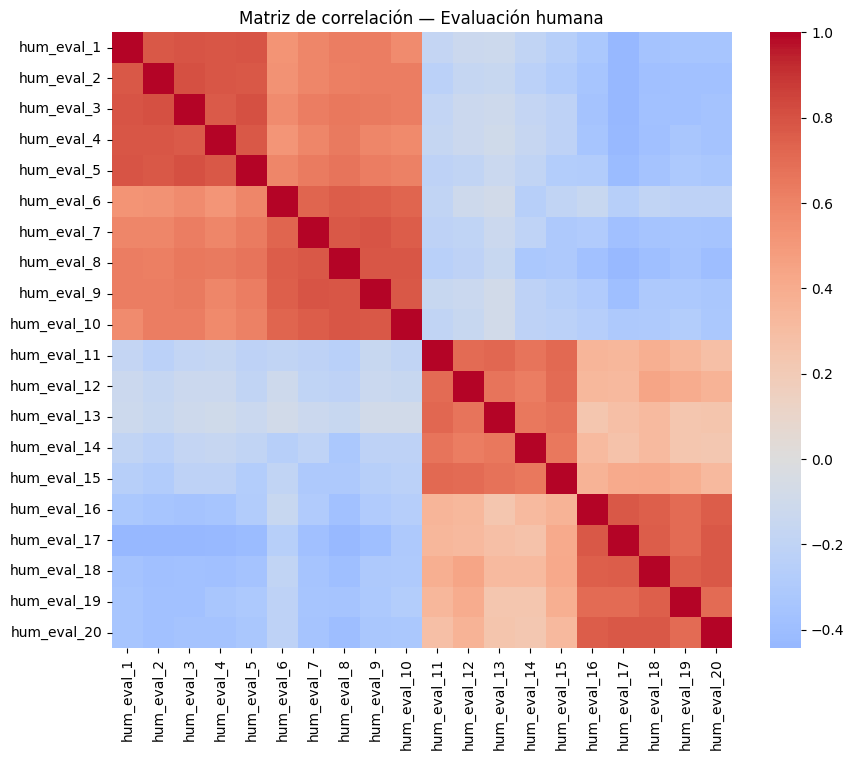

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(hum_data.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación — Evaluación humana")
plt.show()

In [ ]:
# ESPECIFICACIÓN DEL MODELO CFA

model_desc = """
Calidad =~ hum_eval_1 + hum_eval_2 + hum_eval_3 + hum_eval_4 + hum_eval_5
Seguridad =~ hum_eval_6 + hum_eval_7 + hum_eval_8 + hum_eval_9 + hum_eval_10
Creatividad =~ hum_eval_11 + hum_eval_12 + hum_eval_13 + hum_eval_14 + hum_eval_15
Sesgo =~ hum_eval_16 + hum_eval_17 + hum_eval_18 + hum_eval_19 + hum_eval_20
"""

model = Model(model_desc)

In [ ]:
# AJUSTE DEL MODELO

res = model.fit(hum_data)
print("Modelo ajustado correctamente")

Modelo ajustado correctamente


In [ ]:
# ÍNDICES DE AJUSTE GLOBAL

stats = calc_stats(model)
fit = stats.loc["Value"]

print("Chi2 :", fit.get("chi2"))
print("RMSEA:", fit.get("RMSEA"))
print("CFI  :", fit.get("CFI"))
print("SRMR :", fit.get("SRMR")) # Como se esta calculadno todo estoy y Porque no me calcula srmr

Chi2 : 192.53675081209389
RMSEA: 0.029570168496938005
CFI  : 0.9919773932940105
SRMR : None


In [ ]:
# CARGAS FACTORIALES ESTIMADAS

estimates = model.inspect()
loadings = estimates[estimates["op"] == "~"]
loadings = loadings[["lval","rval","Estimate"]]

loadings

,lval,rval,Estimate
0,hum_eval_1,Calidad,1.000000
1,hum_eval_2,Calidad,1.052459
2,hum_eval_3,Calidad,1.071438
3,hum_eval_4,Calidad,1.023496
4,hum_eval_5,Calidad,0.978973
5,hum_eval_6,Seguridad,1.000000
6,hum_eval_7,Seguridad,1.087795
7,hum_eval_8,Seguridad,1.233430
8,hum_eval_9,Seguridad,1.087347
9,hum_eval_10,Seguridad,1.155046


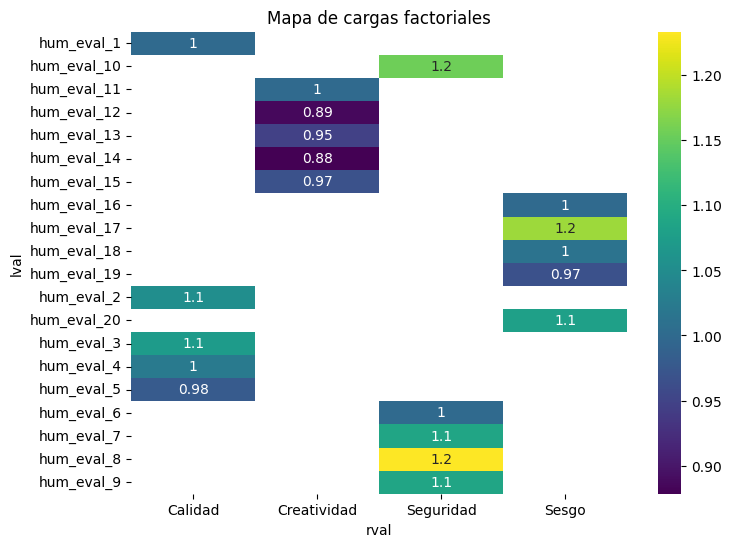

In [ ]:
pivot_load = loadings.pivot(index="lval", columns="rval", values="Estimate")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_load, annot=True, cmap="viridis")
plt.title("Mapa de cargas factoriales")
plt.show()

Parte 2

In [ ]:
# MATRIZ DE VARIABLES COMPLETA

X = data.drop(columns=["prompt_id"])

print("Dimensiones X:", X.shape)
X.head()

Dimensiones X: (200, 3000)


,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
0,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,2.309524,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
1,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,-0.568507,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
2,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,1.522270,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
3,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,0.000648,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
4,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,0.423968,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


In [ ]:
# ESCALADO

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# PCA COMPLETO

pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained)

In [ ]:
# SELECCIÓN DE m COMPONENTES

m = np.argmax(cum_var >= 0.80) + 1
print("Número de componentes retenidos:", m)

Número de componentes retenidos: 128


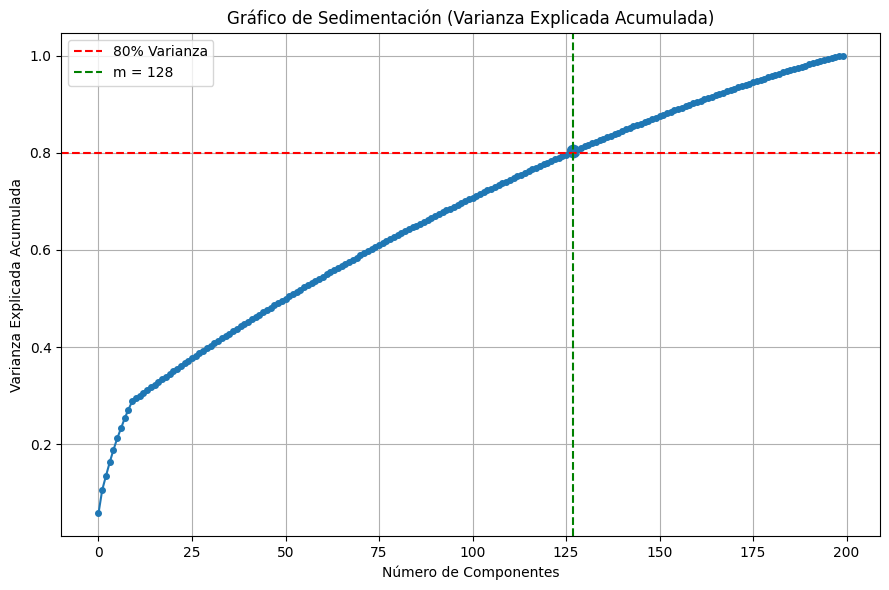

In [ ]:
# SCREE PLOT
plt.figure(figsize=(9,6))

# Curva de varianza acumulada
plt.plot(cum_var, marker='o', markersize=4)

# Línea horizontal 80%
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Varianza')

# Línea vertical en m componentes
plt.axvline(x=m-1, color='g', linestyle='--', label=f'm = {m}')

# Punto exacto seleccionado
plt.scatter(m-1, cum_var[m-1], s=80)

plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Gráfico de Sedimentación (Varianza Explicada Acumulada)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# PCA DEFINITIVO

pca = PCA(n_components=m)
scores = pca.fit_transform(X_scaled)

In [ ]:
# ROTACIÓN VARIMAX

rotator = Rotator(method="varimax")
loadings_rot = rotator.fit_transform(pca.components_.T)

In [ ]:
# SCORES ROTADOS

scores_rot = X_scaled @ loadings_rot

scores_df = pd.DataFrame(
    scores_rot,
    columns=[f"Factor_{i+1}" for i in range(m)]
)

scores_df.head()

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,...,Factor_119,Factor_120,Factor_121,Factor_122,Factor_123,Factor_124,Factor_125,Factor_126,Factor_127,Factor_128
0,-0.315310,12.187812,-0.870783,0.683537,-5.487625,4.360791,-4.838607,2.597953,4.401427,7.806606,...,1.958993,2.591776,-1.081068,-2.774532,-2.929217,7.870343,3.014702,0.835158,-1.639501,1.905050
1,-3.147607,3.836759,5.635899,4.505582,-3.295027,-0.269438,-6.699215,-1.739401,11.536126,5.138346,...,-1.409181,-7.254395,-8.511815,1.148273,9.001624,7.958439,-1.585216,0.733183,-2.692360,4.746102
2,2.619406,-3.427613,-2.675128,-0.336874,0.362684,1.954912,2.085586,8.034236,3.681933,2.516011,...,-2.239999,-0.154439,1.050053,-0.335769,-2.715574,2.068860,-6.884839,-2.379398,2.423803,-0.115858
3,-0.116616,-5.437434,6.408313,-2.050069,4.523131,-3.292962,-1.395601,-4.039599,1.417913,-3.058564,...,-0.754301,-2.577466,-11.987659,5.560684,-3.518095,4.859414,-1.141803,1.122608,-4.811593,0.229393
4,-2.262127,0.122239,4.372384,-2.467254,10.975578,-1.894378,-2.881083,-4.114794,6.421611,-7.843396,...,2.661948,4.633603,0.807478,1.230607,4.034074,2.503438,2.450504,6.607484,-4.333718,2.536747


In [ ]:
# COMPARACIÓN DIMENSIONAL

print("Dimensión original:", X.shape[1])
print("Dimensión reducida:", scores_df.shape[1])

Dimensión original: 3000
Dimensión reducida: 128


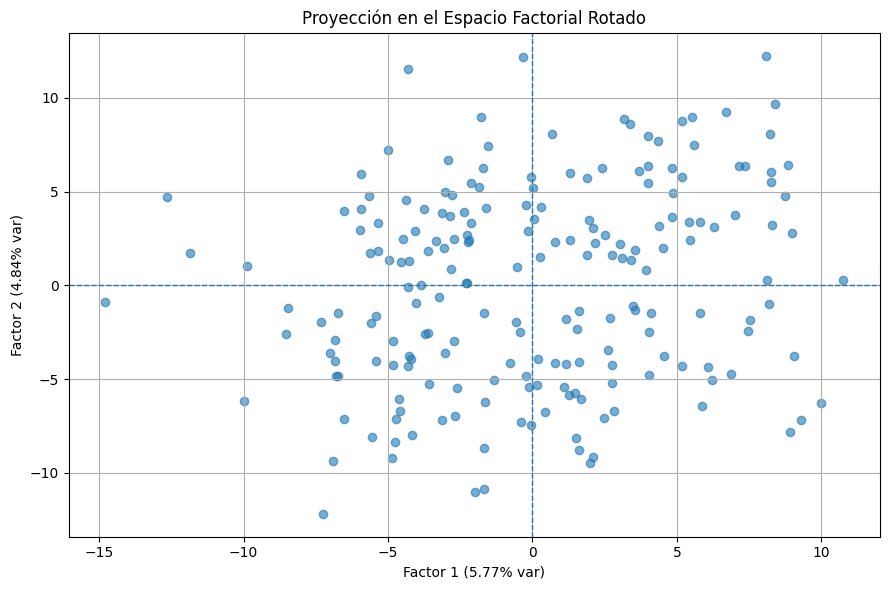

In [ ]:
# VISUALIZACIÓN 2D
if m >= 2:

    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100

    plt.figure(figsize=(9,6))

    plt.scatter(scores_df.iloc[:,0],
                scores_df.iloc[:,1],
                alpha=0.6)

    # Líneas de referencia en cero
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.axvline(0, linestyle='--', linewidth=1)

    plt.xlabel(f"Factor 1 ({var1:.2f}% var)")
    plt.ylabel(f"Factor 2 ({var2:.2f}% var)")
    plt.title("Proyección en el Espacio Factorial Rotado")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Parte 3

In [ ]:
# USAR SCORES DEL PCA ROTADO

scores_df = pd.DataFrame(
    scores_rot,
    columns=[f"Factor_{i+1}" for i in range(m)]
)

In [ ]:
# ESCALAMIENTO

scaler = StandardScaler()
scores_scaled = scaler.fit_transform(scores_df)

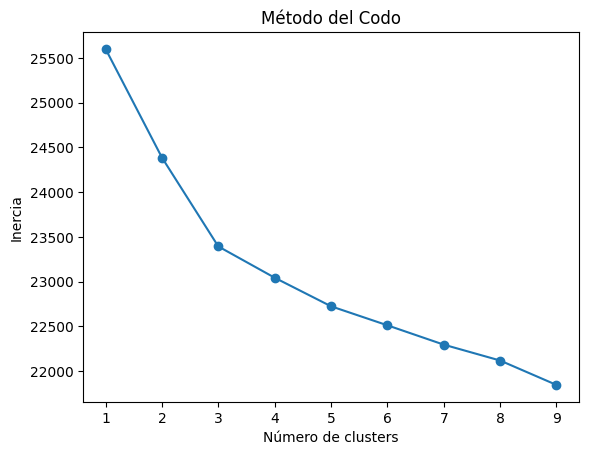

In [ ]:
# METODO DEL CODO

inertia = []

K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scores_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

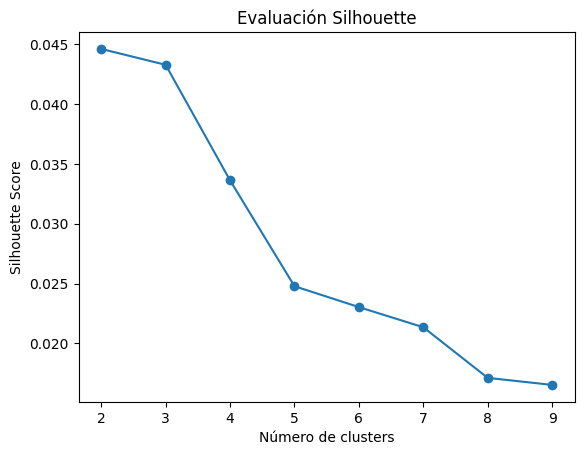

In [ ]:
# SILHOUETTE SCORE

sil_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scores_scaled)
    sil_scores.append(silhouette_score(scores_scaled, labels))

plt.plot(range(2,10), sil_scores, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Evaluación Silhouette")
plt.show()

In [ ]:
# MODELO FINAL

k_opt = 3

kmeans_final = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(scores_scaled)

scores_df["Cluster"] = clusters
scores_df.head()

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,...,Factor_120,Factor_121,Factor_122,Factor_123,Factor_124,Factor_125,Factor_126,Factor_127,Factor_128,Cluster
0,-0.315310,12.187812,-0.870783,0.683537,-5.487625,4.360791,-4.838607,2.597953,4.401427,7.806606,...,2.591776,-1.081068,-2.774532,-2.929217,7.870343,3.014702,0.835158,-1.639501,1.905050,0
1,-3.147607,3.836759,5.635899,4.505582,-3.295027,-0.269438,-6.699215,-1.739401,11.536126,5.138346,...,-7.254395,-8.511815,1.148273,9.001624,7.958439,-1.585216,0.733183,-2.692360,4.746102,1
2,2.619406,-3.427613,-2.675128,-0.336874,0.362684,1.954912,2.085586,8.034236,3.681933,2.516011,...,-0.154439,1.050053,-0.335769,-2.715574,2.068860,-6.884839,-2.379398,2.423803,-0.115858,2
3,-0.116616,-5.437434,6.408313,-2.050069,4.523131,-3.292962,-1.395601,-4.039599,1.417913,-3.058564,...,-2.577466,-11.987659,5.560684,-3.518095,4.859414,-1.141803,1.122608,-4.811593,0.229393,1
4,-2.262127,0.122239,4.372384,-2.467254,10.975578,-1.894378,-2.881083,-4.114794,6.421611,-7.843396,...,4.633603,0.807478,1.230607,4.034074,2.503438,2.450504,6.607484,-4.333718,2.536747,1


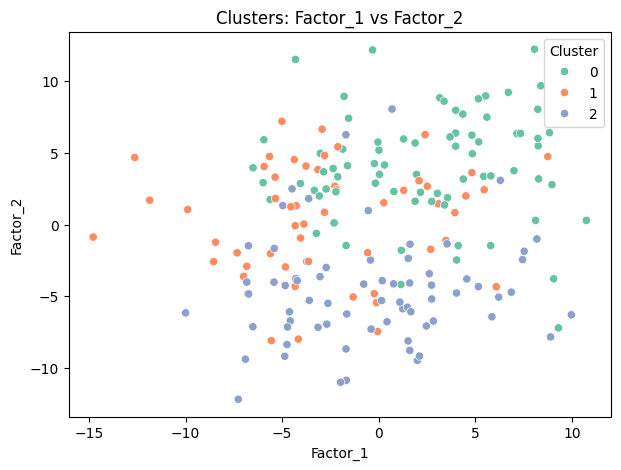

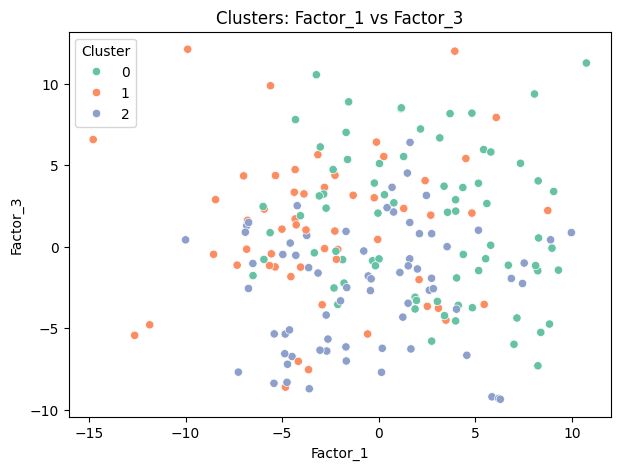

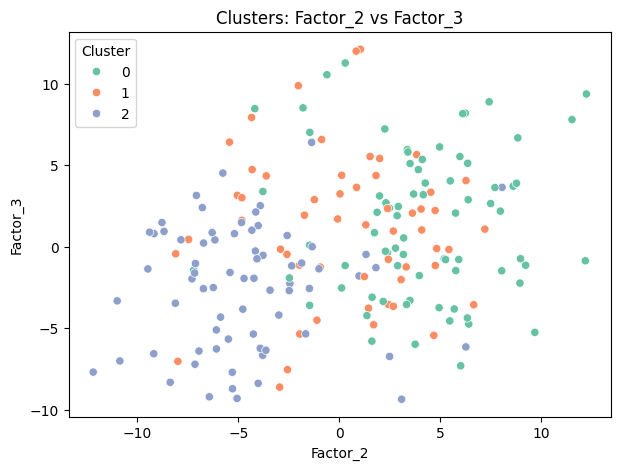

In [ ]:
pairs = [
    ("Factor_1","Factor_2"),
    ("Factor_1","Factor_3"),
    ("Factor_2","Factor_3")
]

for x,y in pairs:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=x, y=y, hue="Cluster", palette="Set2", data=scores_df)
    plt.title(f"Clusters: {x} vs {y}")
    plt.show()

In [ ]:
# ANALISIS DE PERFILES

cluster_profile = scores_df.groupby("Cluster").mean()
cluster_profile

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,...,Factor_119,Factor_120,Factor_121,Factor_122,Factor_123,Factor_124,Factor_125,Factor_126,Factor_127,Factor_128
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.352953,4.071368,1.493745,0.968576,0.608506,0.811566,1.203223,1.303842,-1.330465,0.158120,...,-0.099611,-0.289048,1.777299,-1.544478,0.456829,-1.501688,-0.936511,0.677216,0.569488,0.785303
1,-2.728279,0.342940,1.139596,-1.488372,2.055260,-1.620760,-1.056974,-2.558852,2.701240,0.695482,...,-0.213829,0.321312,-2.281825,1.457160,-0.807835,2.522907,1.514349,0.423935,-0.350215,0.116436
2,-0.377373,-4.631633,-2.495838,0.131676,-2.266818,0.403919,-0.458687,0.613553,-0.696904,-0.715864,...,0.274734,0.057234,-0.111387,0.509887,0.145268,-0.373332,-0.186441,-1.058680,-0.334997,-0.932881


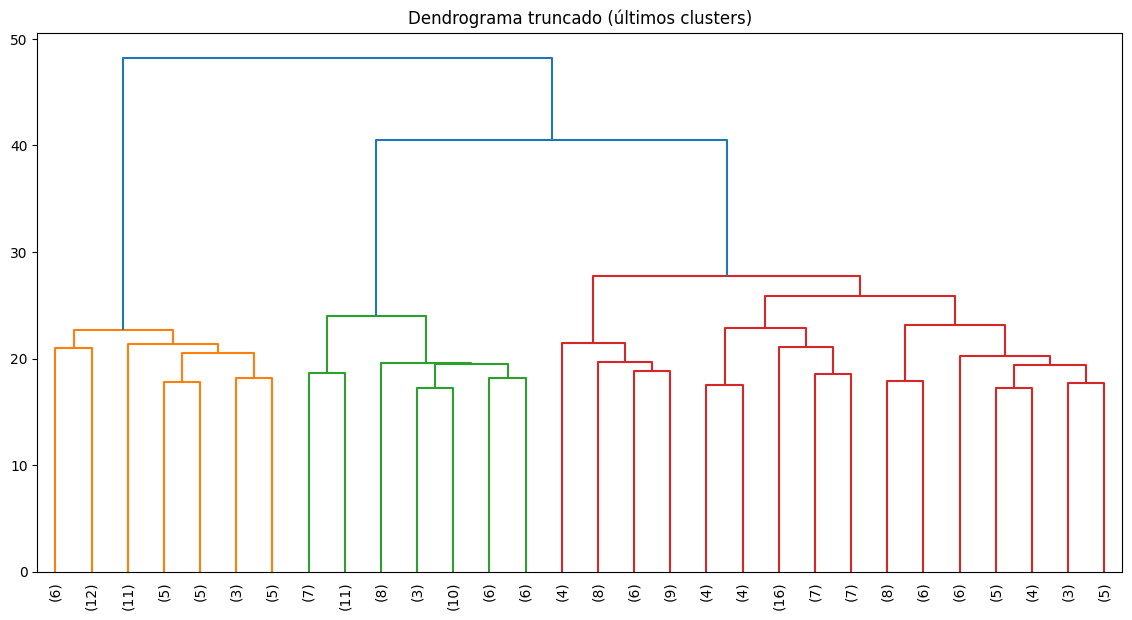

In [ ]:
# DENDOGRAMA JERARQUICO


Z = linkage(scores_scaled, method="ward")

plt.figure(figsize=(14,7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Dendrograma truncado (últimos clusters)")
plt.show()

In [ ]:
# SILHOUETTE EN ESPACIO FACTORIAL PCA

X = scores_df   # <- usar TODOS los factores

for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k} -> silhouette={score:.3f}")

k=2 -> silhouette=0.048
k=3 -> silhouette=0.049
k=4 -> silhouette=0.036
k=5 -> silhouette=0.030
k=6 -> silhouette=0.024


In [ ]:
# MODELO FINAL KMEANS EN ESPACIO FACTORIAL PCA

kmeans_final = KMeans(
    n_clusters=3,   # k óptimo según silueta
    random_state=42,
    n_init=10
)

scores_df["Cluster"] = kmeans_final.fit_predict(
    scores_df.drop(columns="Cluster", errors="ignore")
)

Parte 4

In [ ]:
# PROMEDIOS POR CLUSTER

cluster_summary = scores_df.groupby("Cluster").mean()

cluster_summary

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8,Factor_9,Factor_10,...,Factor_119,Factor_120,Factor_121,Factor_122,Factor_123,Factor_124,Factor_125,Factor_126,Factor_127,Factor_128
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.145386,4.140186,1.541434,1.014081,0.700003,0.705562,1.231815,1.235771,-1.127213,0.306196,...,-0.221289,-0.294728,1.742784,-1.681704,0.292494,-1.474747,-1.006754,0.616469,0.436708,0.858025
1,-0.076921,-4.547557,-2.321332,0.054801,-2.101642,0.357643,-0.457778,0.679972,-0.793793,-0.542665,...,0.193972,-0.045562,-0.146390,0.580036,0.225567,-0.448437,-0.170057,-0.968137,-0.212295,-0.734767
2,-3.102697,0.611056,1.169846,-1.603323,2.102458,-1.594808,-1.161055,-2.873615,2.881510,0.354702,...,0.040975,0.510435,-2.394592,1.652501,-0.777091,2.884776,1.765217,0.527503,-0.336619,-0.184887


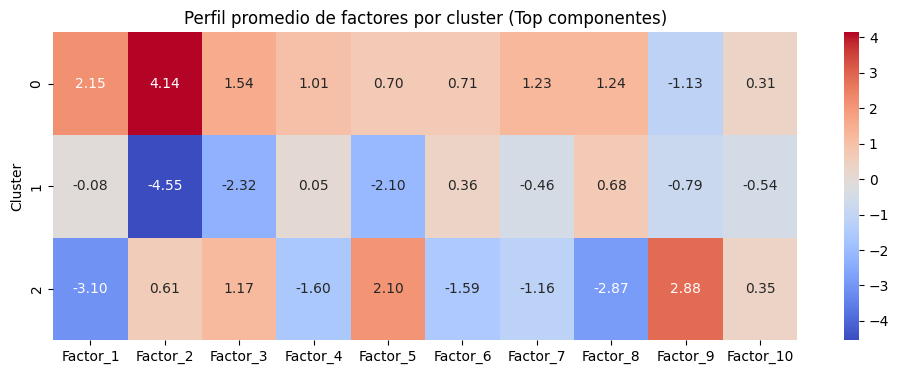

In [ ]:
# HEATMAP

# Seleccionar primeros componentes importantes
n_comp = 10
cluster_summary_small = cluster_summary.iloc[:, :n_comp]

plt.figure(figsize=(12,4))

sns.heatmap(
    cluster_summary_small,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Perfil promedio de factores por cluster (Top componentes)")
plt.show()


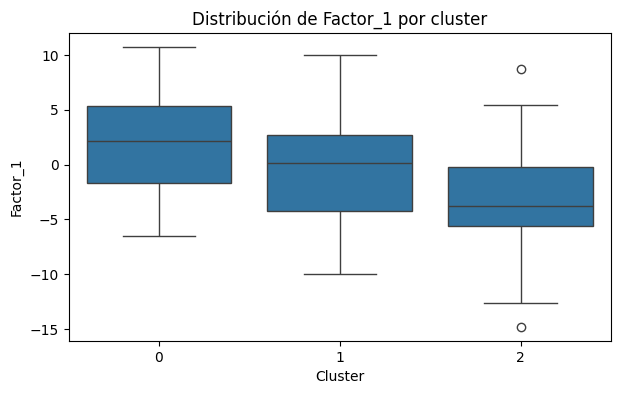

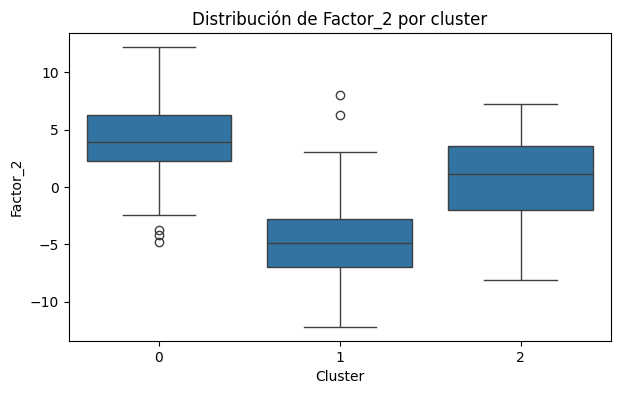

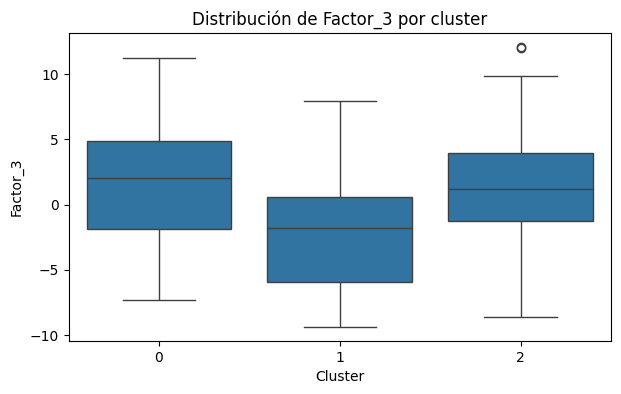

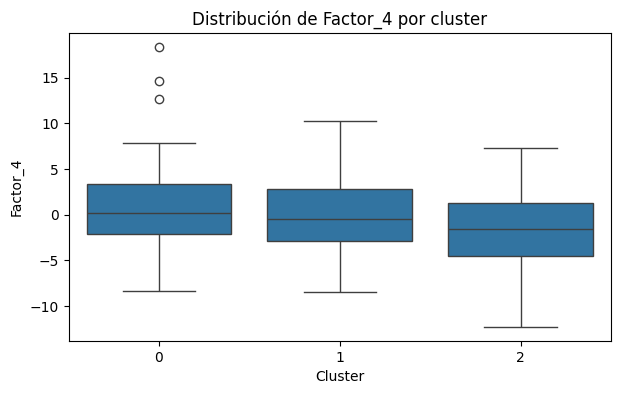

In [ ]:
# DISTRIBUCION DE CADA FACTOR POR CLUSTER

factores = scores_df.drop(columns="Cluster").columns[:4]

for f in factores:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="Cluster", y=f, data=scores_df)
    plt.title(f"Distribución de {f} por cluster")
    plt.show()


In [ ]:
# TAMAÑO DE CADA CLUSTER

cluster_sizes = scores_df["Cluster"].value_counts().sort_index()

print(cluster_sizes)

Cluster
0    75
1    75
2    50
Name: count, dtype: int64
